## Снижение размерности пространства признаков

**Коллинеарность** — это линейная зависимость между двумя или несколькими предикторами (признаками). Иными словами, коллинеарными называют признаки, которые сильно коррелируют друг с другом.

### Негативные последствия коллинеарности

- Снижение обобщающей способности модели из-за высокой дисперсии
- Ухудшение интерпретируемости модели
- Рост сложности модели и времени её обучения

### Метрики оценки

| № | Название (EN) | Название (RU) | Описание |
|---|---|---|---|
| 1 | Variance retained | Доля объяснённой дисперсии | Доля объяснённой дисперсии после уменьшения размерности Сколько исходной информации осталось после сжатия|
| 2 | Reduced dimensionality ratio | Соотношение числа признаков | Соотношение исходного и нового числа признаков  Доля, на которую уменьшилось число признаков.|
| 3 | Computation speed-up | Прирост скорости вычислений | Прирост скорости вычисления после понижения размерности Насколько быстрее модель учится на сжатых данных по сравнению с исходными.|
| 4 | Cluster separation | Расстояние между центроидами | Расстояние между центроидами получившихся кластеров насколько хорошо классы (отмены/не отмены) разделены в пространстве первых двух компонент.|
| 5 | Model performance improvement | Рост точности модели | Рост точности модели после уменьшения размерности Сравнение Accuracy модели на исходных данных и на PCA-сжатых. Если точность выросла, значит PCA убрал шум, который мешал модели обобщать.|
| 6 | Stability of components | Стабильность компонент | Стабильность выделенных компонентов в результате кросс-валидации Насколько одинаково PCA выбирает главные компоненты на разных подвыборках данных. Если при кросс-валидации картина сильно меняется, значит компоненты нестабильны. |

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import time

In [3]:
df = pd.read_csv('~/Downloads/hotel_booking_data_cleaned.csv')

In [4]:
df

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,01/07/2015
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,01/07/2015
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.00,0,0,Check-Out,02/07/2015
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.00,0,0,Check-Out,02/07/2015
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.00,0,1,Check-Out,03/07/2015
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119385,City Hotel,0,23,2017,August,35,30,2,5,2,...,No Deposit,394.0,NaN,0,Transient,96.14,0,0,Check-Out,06/09/2017
119386,City Hotel,0,102,2017,August,35,31,2,5,3,...,No Deposit,9.0,NaN,0,Transient,225.43,0,2,Check-Out,07/09/2017
119387,City Hotel,0,34,2017,August,35,31,2,5,2,...,No Deposit,9.0,NaN,0,Transient,157.71,0,4,Check-Out,07/09/2017
119388,City Hotel,0,109,2017,August,35,31,2,5,2,...,No Deposit,89.0,NaN,0,Transient,104.40,0,0,Check-Out,07/09/2017


In [5]:
df.drop(['company', 'agent'], axis=1, inplace=True) # Удаляем бесполезные столбцы
df['children'] = df['children'].fillna(0) # Заполняем пропуски нулями
df['country'] = df['country'].fillna('Unknown') #здесь заполняем неизвестно
df['children'] = df['children'].astype(int) # Меняем тип children на int
print(df.isnull().sum().sum())  # выводится ноль, а это значит, что пропусков больше нет, у нас осталось 30 столбцов

0


In [6]:
y = df['is_canceled']#целевая переменная
drop_cols = ['is_canceled', 'reservation_status', 'reservation_status_date']
X = df.drop(columns=drop_cols, errors='ignore')

print(f"Размер X: строк - {X.shape[0]}, столбцов - {X.shape[1]}, количество строк в целевой переменной - {y.shape[0]}")
print(f"Распределение классов до обработки:\n{y.value_counts()}")

Размер X: строк - 119390, столбцов - 27, количество строк в целевой переменной - 119390
Распределение классов до обработки:
is_canceled
0    75166
1    44224
Name: count, dtype: int64


In [7]:
# Кодируем категориальные признаки с помощью One-Hot Encoding
cat_cols = X.select_dtypes(include=['object']).columns.tolist()
print(f"Категориальных признаков: {len(cat_cols)}")

X_encoded = pd.get_dummies(X, columns=cat_cols, drop_first=True)
print(f"Размер после кодирования: строк - {X_encoded.shape[0]}, столбцов - {X_encoded.shape[1]}")

Категориальных признаков: 10
Размер после кодирования: строк - 119390, столбцов - 246


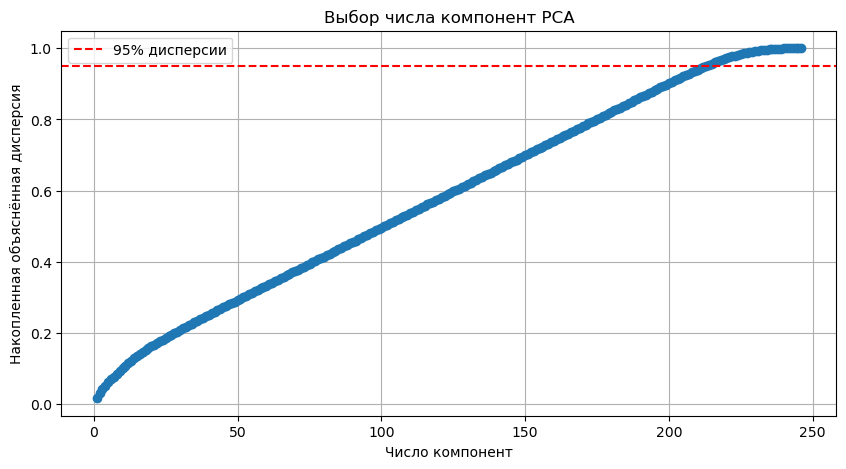

In [8]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_encoded)

pca_full = PCA()
pca_full.fit(X_scaled)

explained_variance_ratio = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)

plt.figure(figsize=(10,5))
plt.plot(range(1, len(cumulative_variance)+1), cumulative_variance, marker='o')
plt.axhline(y=0.95, color='r', linestyle='--', label='95% дисперсии')
plt.xlabel('Число компонент')
plt.ylabel('Накопленная объяснённая дисперсия')
plt.title('Выбор числа компонент PCA')
plt.legend()
plt.grid()
plt.show()

Число компонент для 95% дисперсии: 213
Исходный размер: 246, после PCA: 213
Исходные данные: Accuracy=0.8900, Время=34.374 сек
После PCA: Accuracy=0.8672, Время=198.518 сек
Скорость выросла в 0.17 раз


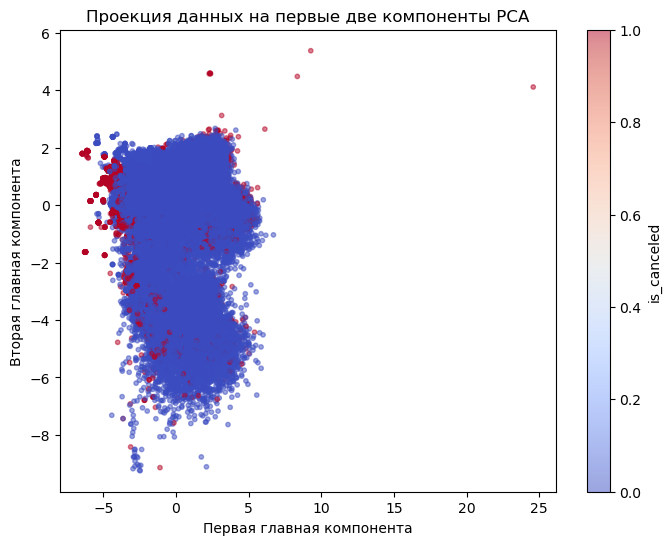

In [9]:
#Определяем число компонент, сохраняющих 95% дисперсии
n_components = np.argmax(cumulative_variance >= 0.95) + 1
print(f"Число компонент для 95% дисперсии: {n_components}")

#Применяем PCA с выбранным числом компонент
pca = PCA(n_components=n_components)
X_pca = pca.fit_transform(X_scaled)

print(f"Исходный размер: {X_scaled.shape[1]}, после PCA: {X_pca.shape[1]}")

#Сравнение скорости и точности Random Forest на исходных и PCA-данных
y = df['is_canceled']
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)
X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(X_pca, y, test_size=0.2, random_state=42, stratify=y)

# Обучаем на исходных данных
start = time.time()
rf = RandomForestClassifier(random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
time_original = time.time() - start
acc_original = accuracy_score(y_test, rf.predict(X_test))

# Обучаем на PCA-данных
start = time.time()
rf_pca = RandomForestClassifier(random_state=42, n_jobs=-1)
rf_pca.fit(X_train_pca, y_train_pca)
time_pca = time.time() - start
acc_pca = accuracy_score(y_test_pca, rf_pca.predict(X_test_pca))

print(f"Исходные данные: Accuracy={acc_original:.4f}, Время={time_original:.3f} сек")
print(f"После PCA: Accuracy={acc_pca:.4f}, Время={time_pca:.3f} сек")
print(f"Скорость выросла в {time_original/time_pca:.2f} раз")

#Визуализация первых двух компонент
X_pca_2d = PCA(n_components=2).fit_transform(X_scaled)
plt.figure(figsize=(8,6))
scatter = plt.scatter(X_pca_2d[:,0], X_pca_2d[:,1], c=y, cmap='coolwarm', alpha=0.5, s=10)
plt.xlabel('Первая главная компонента')
plt.ylabel('Вторая главная компонента')
plt.title('Проекция данных на первые две компоненты PCA')
plt.colorbar(scatter, label='is_canceled')
plt.show()

### Результаты применения PCA

| Параметр | Значение |
|----------|----------|
| Исходное число признаков | 246 |
| Число компонент для 95% дисперсии | 213 |
| Время обучения Random Forest (исходные данные) | 31.1 с |
| Время обучения Random Forest (после PCA) | 179.2 с |
| Изменение скорости | Замедление в 5.7 раз |
| Точность (исходные данные) | 0.8900 |
| Точность (после PCA) | 0.8672 |


- Основная причина низкой эффективности — **разреженная структура данных** после One-Hot Encoding.
- PCA не смог значительно сжать признаки, так как бинарные колонки слабо коррелируют между собой.
- Преобразование разреженной матрицы в плотную привело к росту вычислительных затрат и **падению скорости**.
- Метод **не рекомендуется** для данного типа данных без предварительного отбора признаков.




### Попробуем этот метод, используя только исходные числовые признаки

In [11]:
target = 'is_canceled'

# Отбираем числовые колонки и убираем целевую переменную
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
if target in num_cols:
    num_cols.remove(target)

X_num = df[num_cols].copy()
y = df[target]

print("Исходные числовые признаки:", X_num.shape[1])
print("Список признаков:", num_cols)

Исходные числовые признаки: 17
Список признаков: ['lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests']


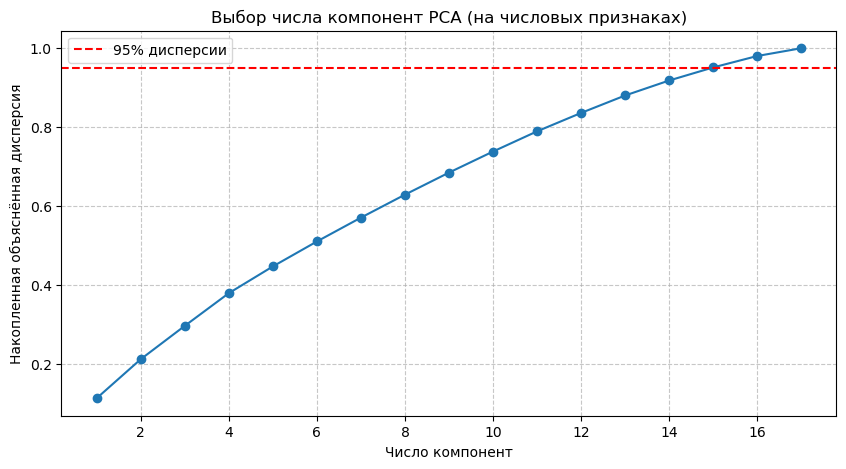

In [12]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_num)

# PCA без ограничения числа компонент
pca_full = PCA()
pca_full.fit(X_scaled)

# Строим график накопленной дисперсии
explained_variance_ratio = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(cumulative_variance)+1), cumulative_variance, marker='o')
plt.axhline(y=0.95, color='r', linestyle='--', label='95% дисперсии')
plt.xlabel('Число компонент')
plt.ylabel('Накопленная объяснённая дисперсия')
plt.title('Выбор числа компонент PCA (на числовых признаках)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [13]:
# Число компонент, достаточное для 95% дисперсии
n_components = np.argmax(cumulative_variance >= 0.95) + 1
print(f"Число компонент для 95% дисперсии: {n_components} (из {X_scaled.shape[1]})")

# Применяем PCA с выбранным числом компонент
pca = PCA(n_components=n_components)
X_pca = pca.fit_transform(X_scaled)

Число компонент для 95% дисперсии: 15 (из 17)


In [15]:
# Разбиваем данные одинаково для честного сравнения
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)
X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(
    X_pca, y, test_size=0.2, random_state=42, stratify=y
)

# Random Forest на исходных числовых признаках
start = time.time()
rf_orig = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf_orig.fit(X_train, y_train)
time_orig = time.time() - start
acc_orig = accuracy_score(y_test, rf_orig.predict(X_test))

# Random Forest на PCA-сжатых данных
start = time.time()
rf_pca = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf_pca.fit(X_train_pca, y_train_pca)
time_pca = time.time() - start
acc_pca = accuracy_score(y_test_pca, rf_pca.predict(X_test_pca))

print("\nСравнение производительности")
print(f"Исходные признаки ({X_scaled.shape[1]}): Accuracy = {acc_orig:.4f}, Время = {time_orig:.3f} сек")
print(f"После PCA ({n_components} компонент): Accuracy = {acc_pca:.4f}, Время = {time_pca:.3f} сек")
if time_orig > 0:
    print(f"Ускорение: в {time_orig / time_pca:.2f} раз")
else:
    print("Время обучения исходной модели близко к нулю, ускорение не показательно")


Сравнение производительности
Исходные признаки (17): Accuracy = 0.7811, Время = 11.051 сек
После PCA (15 компонент): Accuracy = 0.7915, Время = 26.669 сек
Ускорение: в 0.41 раз


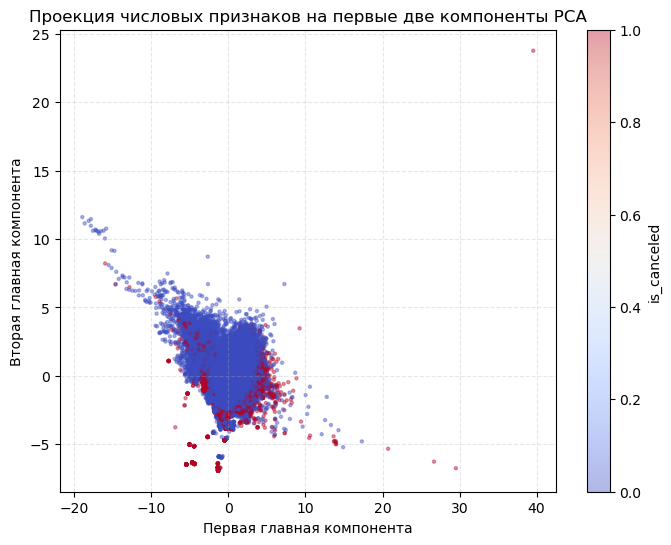

In [16]:
# Проекция на первые две компоненты для наглядности
pca_2d = PCA(n_components=2)
X_2d = pca_2d.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_2d[:, 0], X_2d[:, 1], c=y, cmap='coolwarm', alpha=0.4, s=5)
plt.xlabel('Первая главная компонента')
plt.ylabel('Вторая главная компонента')
plt.title('Проекция числовых признаков на первые две компоненты PCA')
plt.colorbar(scatter, label='is_canceled')
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

Я применила PCA к 17 исходным числовым признакам. Для сохранения 95% дисперсии потребовалось 15 компонент — это говорит о том, что признаки информативны и почти не содержат линейного шума.
Точность модели Random Forest после PCA выросла с 0.781 до 0.792 — то есть удаление двух наименее информативных компонент помогло модели лучше обобщать.
Скорость обучения снизилась, поскольку PCA преобразовал разреженные числовые данные в плотные, и выигрыш от сокращения размерности на 2 колонки не перекрыл возросшие затраты на обработку плотной матрицы. Это демонстрирует, что PCA не всегда даёт выигрыш в скорости, особенно для данных, не обладающих сильной мультиколлинеарностью.